# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [2]:
! git clone https://github.com/JasonYe05/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 33, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 33 (delta 9), reused 5 (delta 5), pack-reused 20 (from 1)
Receiving objects: 100% (33/33), 32.57 KiB | 16.29 MiB/s, done.
Resolving deltas: 100% (10/10), done.
Download complete
Extracting data files...
Data extracted


**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Linear models are used because they are interpretable. However, sometimes linear models can not accomade reasonable restrictions on the outcomes. General linear models explains when logistic, multinomial logistic, and Poisson regression are used.
2. One gives us the likelihood function for regression and the other says we take the logs because the likelihood is a product of probabilities, it then shows that the log likelihood and binary cross entropy have the exact same solution.
3. This statement is true. It states that its a non linear model unless A(L) = L. It also says that not linear overall because of activation function.
4. False, because logistic regression is or can be used for both regression and for classification.
5. No, we do not interpret the coefficient as simple proportional change in y. Because in the non linear models changes in x don't impact changes in y in proportion to b.
6. False, FE is not unnecessary just because logistic regression is nonlnear. Taking a latent index over a carefully engineered feature space. Logistic regression is nonlinear soley due to the fact of the activation function.
7. False, binary outcomes use logistic regression, categorical outcomes use multimonial logistics regression, and count outcomes use Poisson regression.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

5. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

6. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [3]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
import statsmodels.api as sm

df = pd.read_csv("/content/data.csv", sep=";")

cols = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target"
]
df = df[cols].copy()

print("Missing values:")
print(df.isna().sum())


df["dropout"] = (df["Target"] == "Dropout").astype(int) #this here creats the binary for 2-5

Missing values:
Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64


In [4]:
#2
X = df[["Debtor", "Tuition fees up to date", "Scholarship holder", "Age at enrollment"]]
y = df["dropout"]

logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

print("\nLogistic regression coefficients:")
for name, coef in zip(X.columns, logit.coef_[0]):
    print(f"{name}: {coef:.4f}")
print("Intercept:", logit.intercept_[0])


Logistic regression coefficients:
Debtor: 0.5306
Tuition fees up to date: -2.5565
Scholarship holder: -1.2274
Age at enrollment: 0.0499
Intercept: 0.4856926578796168


Looking at this Debtor and Age at enrollment both have a positive coefficient, so students have a higher dropout rate. Tution fees up to date and scholarship holder both are negative so they are associated with a lower dropout rate. So being up to date on tuition does seem to reduce dropout, and it is the stronger factor in the model.

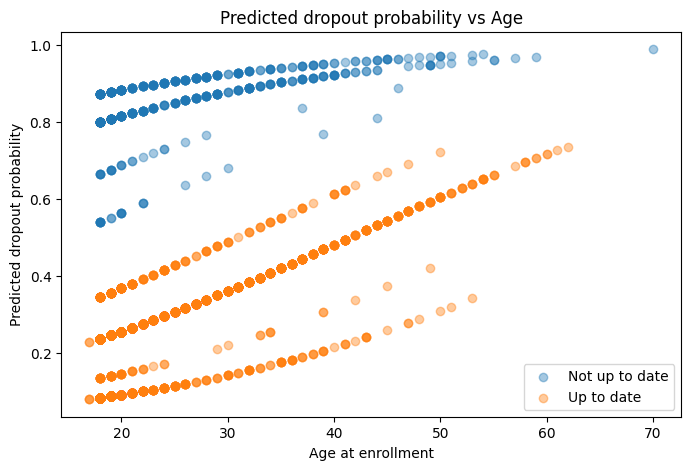


Average reduction in predicted dropout probability
from being up to date on tuition: 0.5161819741831828

Average tuition effect by age:
     Reduction from being up to date
Age                                 
22                          0.537499
23                          0.535802
21                          0.535541
20                          0.532669
24                          0.531446
19                          0.529255
25                          0.527728
26                          0.527287
18                          0.525951
27                          0.524518


In [5]:
#3
df["logit_prob"] = logit.predict_proba(X)[:, 1]

plt.figure(figsize=(8, 5))
for tuition_value, label in [(0, "Not up to date"), (1, "Up to date")]:
    subset = df[df["Tuition fees up to date"] == tuition_value]
    plt.scatter(
        subset["Age at enrollment"],
        subset["logit_prob"],
        alpha=0.4,
        label=label
    )

plt.xlabel("Age at enrollment")
plt.ylabel("Predicted dropout probability")
plt.title("Predicted dropout probability vs Age")
plt.legend()
plt.show()

X_up = X.copy()
X_up["Tuition fees up to date"] = 1

X_not = X.copy()
X_not["Tuition fees up to date"] = 0

p_up = logit.predict_proba(X_up)[:, 1]
p_not = logit.predict_proba(X_not)[:, 1]

effect = p_not - p_up
print("\nAverage reduction in predicted dropout probability")
print("from being up to date on tuition:", effect.mean())

age_effect = pd.DataFrame({
    "Age": X["Age at enrollment"],
    "Reduction from being up to date": effect
}).groupby("Age").mean()

print("\nAverage tuition effect by age:")
print(age_effect.sort_values("Reduction from being up to date", ascending=False).head(10))

using predict_proba and the scatter plot it looks like the dropout proba against age is around 20-23. By setting Tuition fees up to date = 1 it lowers the probablility of dropout to around 0.5162. So being up to date on tuition lowers the predicted probability of dropout by roughly 51.6 percentage points in this model.

In [6]:
#4
y_pred = logit.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("\nConfusion matrix for binary logistic regression:")
print(cm)
print("Accuracy:", acc)


Confusion matrix for binary logistic regression:
[[2841  162]
 [ 891  530]]
Accuracy: 0.7619801084990958


There's 2841 true negatives; 162 false positives; 891 false negatives; 530 true positives. the accuracy of this was 0.762. This classifer gets around 76.2% of obeservations correct.


Range of linear model predicted probabilities:
Min: 0.05832035022573856
Max: 1.3349535706758708


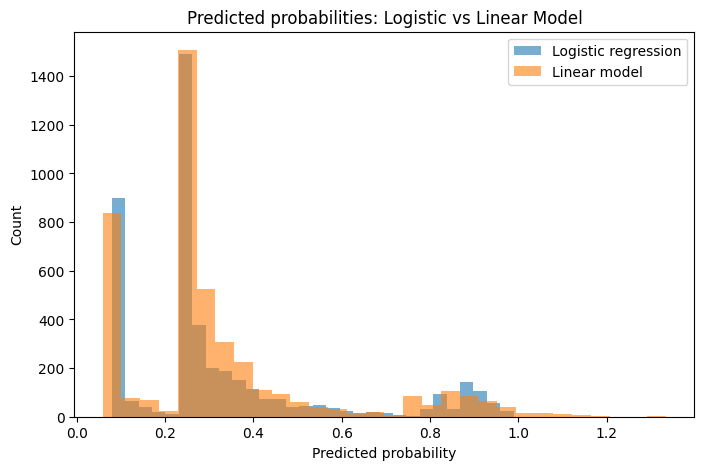

In [7]:
#5
lin = LinearRegression()
lin.fit(X, y)
df["linear_prob"] = lin.predict(X)

print("\nRange of linear model predicted probabilities:")
print("Min:", df["linear_prob"].min())
print("Max:", df["linear_prob"].max())

plt.figure(figsize=(8, 5))
plt.hist(df["logit_prob"], bins=30, alpha=0.6, label="Logistic regression")
plt.hist(df["linear_prob"], bins=30, alpha=0.6, label="Linear model")
plt.xlabel("Predicted probability")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear Model")
plt.legend()
plt.show()

The linear model here predicts that the minimum predicted value is 0.0583 and the max is 1.335. This is a problem because it needs to stay between 0 and 1. So the logistics regression model is more approporiate for modeling the dropout probas. Like in this case even though the histograms look similar, logistic regression is better because it takes the probability structure.

###6
Looking at everything that has been done the highest risk students are: debtors, not upt ot date on tuition, not hold scholarships, entered at older ages. I think some interventions that could be done are financial support for students that are behind on their tuition, grants, more scholarships, etc.

In [8]:
#7
X_multi = df[["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]]
y_multi = df["Target"]

multi_model = LogisticRegression(max_iter=5000, solver="lbfgs")
multi_model.fit(X_multi, y_multi)

multi_pred = multi_model.predict(X_multi)
multi_cm = pd.crosstab(y_multi, multi_pred, rownames=["Actual"], colnames=["Predicted"])
multi_acc = accuracy_score(y_multi, multi_pred)

print("\nMultinomial logistic regression confusion matrix:")
print(multi_cm)
print("Accuracy:", multi_acc)

multi_probs = pd.DataFrame(
    multi_model.predict_proba(X_multi),
    columns=multi_model.classes_
)

print("\nFirst few predicted probabilities:")
print(multi_probs.head())

print("\nPredicted class counts:")
print(pd.Series(multi_pred).value_counts())


Multinomial logistic regression confusion matrix:
Predicted  Dropout  Graduate
Actual                      
Dropout       1054       367
Enrolled       280       514
Graduate       146      2063
Accuracy: 0.7045660036166366

First few predicted probabilities:
    Dropout  Enrolled  Graduate
0  0.680547  0.210464  0.108989
1  0.695414  0.146043  0.158543
2  0.952988  0.041199  0.005813
3  0.117808  0.176983  0.705209
4  0.184227  0.212669  0.603104

Predicted class counts:
Graduate    2944
Dropout     1480
Name: count, dtype: int64


Hard classification doesn't predict every class, the predicted probas includes all classes.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [9]:
#1
df = pd.read_csv("/content/cirrhosis.csv")

cols = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
df = df[cols].copy()

print("Missing values before cleaning:")
print(df.isna().sum())

df_bin = df[["Bilirubin", "Edema", "Drug", "Status"]].dropna().copy()

df_bin["alive"] = df_bin["Status"].isin(["C", "CL"]).astype(int)

X = pd.get_dummies(df_bin[["Edema", "Drug", "Bilirubin"]], drop_first=True)
y = df_bin["alive"]

print("\nRows used for binary model:", len(df_bin))
print("Predictor columns:", X.columns.tolist())

Missing values before cleaning:
Bilirubin      0
Edema          0
Drug         106
Stage          6
Status         0
dtype: int64

Rows used for binary model: 312
Predictor columns: ['Bilirubin', 'Edema_S', 'Edema_Y', 'Drug_Placebo']


For parts 2-5, i dropped all obersvations with missing Drug. Leaving us 312 observations.

In [11]:
#2
logit = LogisticRegression(max_iter=5000)
logit.fit(X, y)

print("\nLogistic regression coefficients:")
for name, coef in zip(X.columns, logit.coef_[0]):
    print(f"{name}: {coef:.4f}")
print("Intercept:", logit.intercept_[0])


Logistic regression coefficients:
Bilirubin: -0.3514
Edema_S: -0.4507
Edema_Y: -1.6110
Drug_Placebo: 0.2312
Intercept: 1.3798277993022918


Here higher bilirubin prdicts a lower probability of survival. Comparing it to with no edema, edema probability of surival drops, and severe edema drops the most.

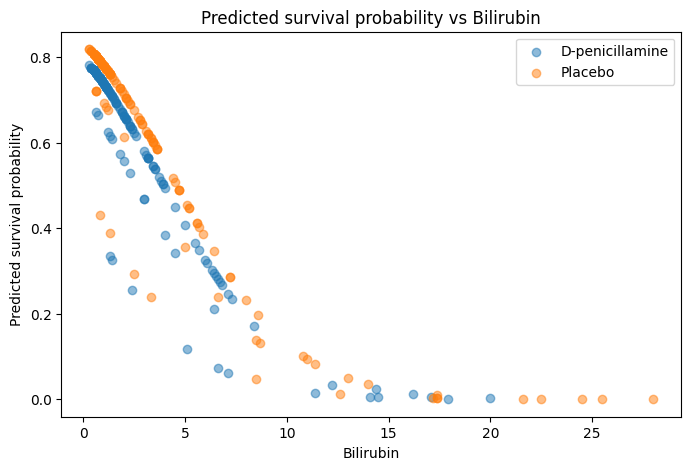


Average change in predicted survival probability
from taking D-penicillamine rather than placebo:
-0.042426639431640066

Average drug effect by bilirubin range:
Bilirubin
(0, 1]      -0.040532
(1, 2]      -0.046648
(2, 3]      -0.052108
(3, 5]      -0.055964
(5, 10]     -0.043324
(10, 100]   -0.004328
Name: drug_effect, dtype: float64


/tmp/ipykernel_19272/749707093.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_bin.groupby(pd.cut(df_bin["Bilirubin"], bins=[0,1,2,3,5,10,100]))["drug_effect"].mean()


In [12]:
#3
df_bin["logit_prob"] = logit.predict_proba(X)[:, 1]

plt.figure(figsize=(8, 5))
for drug_name in ["D-penicillamine", "Placebo"]:
    subset = df_bin[df_bin["Drug"] == drug_name]
    plt.scatter(
        subset["Bilirubin"],
        subset["logit_prob"],
        alpha=0.5,
        label=drug_name
    )

plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival probability vs Bilirubin")
plt.legend()
plt.show()

X_drug = X.copy()
X_drug["Drug_Placebo"] = 0

X_placebo = X.copy()
X_placebo["Drug_Placebo"] = 1

p_drug = logit.predict_proba(X_drug)[:, 1]
p_placebo = logit.predict_proba(X_placebo)[:, 1]

df_bin["drug_effect"] = p_drug - p_placebo

print("\nAverage change in predicted survival probability")
print("from taking D-penicillamine rather than placebo:")
print(df_bin["drug_effect"].mean())

print("\nAverage drug effect by bilirubin range:")
print(
    df_bin.groupby(pd.cut(df_bin["Bilirubin"], bins=[0,1,2,3,5,10,100]))["drug_effect"].mean()
)

Comparing D-penicillamine vs the placebo difference was around 0.0424. So on average taking this drug lowers predicted survival by around 4.2 percentage points relative to placebo. Theres no range where it clearly shows that the drug improves survival.

In [14]:
#4
y_pred = logit.predict(X)
cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("\nConfusion matrix:")
print(cm)
print("Accuracy:", acc)


Confusion matrix:
[[ 59  66]
 [ 16 171]]
Accuracy: 0.7371794871794872


59 true negatives; 66 false positives; 16 false negatives; 171 true positives. The classifier is around 73.7% accurate.


Linear model coefficients:
Bilirubin: -0.0391
Edema_S: -0.1189
Edema_Y: -0.3483
Drug_Placebo: 0.0506
Intercept: 0.7349483967197191

Range of linear predicted probabilities:
Min: -0.4417396683935991
Max: 0.7738680250928711


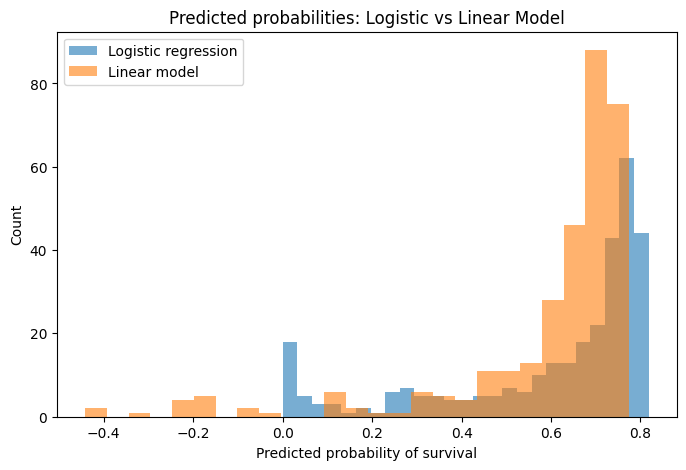

In [15]:
#5
lin = LinearRegression()
lin.fit(X, y)
df_bin["linear_prob"] = lin.predict(X)

print("\nLinear model coefficients:")
for name, coef in zip(X.columns, lin.coef_):
    print(f"{name}: {coef:.4f}")
print("Intercept:", lin.intercept_)

print("\nRange of linear predicted probabilities:")
print("Min:", df_bin["linear_prob"].min())
print("Max:", df_bin["linear_prob"].max())

plt.figure(figsize=(8, 5))
plt.hist(df_bin["logit_prob"], bins=25, alpha=0.6, label="Logistic regression")
plt.hist(df_bin["linear_prob"], bins=25, alpha=0.6, label="Linear model")
plt.xlabel("Predicted probability of survival")
plt.ylabel("Count")
plt.title("Predicted probabilities: Logistic vs Linear Model")
plt.legend()
plt.show()

Linear model is good but a logistic regression may work better since it keeps predictions between 0 and 1 as compared to -0.4417 to 0.7739. negative proba isn't meaningful.

In [16]:
#6
df_stage = df[["Stage", "Edema", "Bilirubin"]].dropna().copy()
df_stage["Stage"] = df_stage["Stage"].astype(int).astype(str)

X_stage = pd.get_dummies(df_stage[["Edema", "Bilirubin"]], drop_first=True)
y_stage = df_stage["Stage"]

multi = LogisticRegression(max_iter=5000)
multi.fit(X_stage, y_stage)

stage_pred = multi.predict(X_stage)
stage_cm = pd.crosstab(y_stage, stage_pred, rownames=["Actual"], colnames=["Predicted"])
stage_acc = accuracy_score(y_stage, stage_pred)

print("\nMultinomial confusion matrix for Stage:")
print(stage_cm)
print("Accuracy:", stage_acc)

stage_probs = pd.DataFrame(
    multi.predict_proba(X_stage),
    columns=multi.classes_
)

print("\nFirst few predicted probabilities:")
print(stage_probs.head())

print("\nPredicted class counts:")
print(pd.Series(stage_pred).value_counts())


Multinomial confusion matrix for Stage:
Predicted    3   4
Actual            
1           20   1
2           82  10
3          130  25
4           93  51
Accuracy: 0.4393203883495146

First few predicted probabilities:
          1         2         3         4
0  0.000469  0.051110  0.137332  0.811088
1  0.068675  0.255046  0.397580  0.278699
2  0.039844  0.139560  0.340088  0.480508
3  0.035217  0.137518  0.338843  0.488422
4  0.035049  0.243194  0.404019  0.317738

Predicted class counts:
3    325
4     87
Name: count, dtype: int64


after running a multinomial logistic regression of Stage on Edema and Bilirubin. As well as dropping the rows missing Stage th accuracy of the table was 0.4393. The multinomial logistic regression gives all positve probas to the 4 stages. But under the hard classification it only predicts stages 3 & 4. Hard classifier doesn't predict every class.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

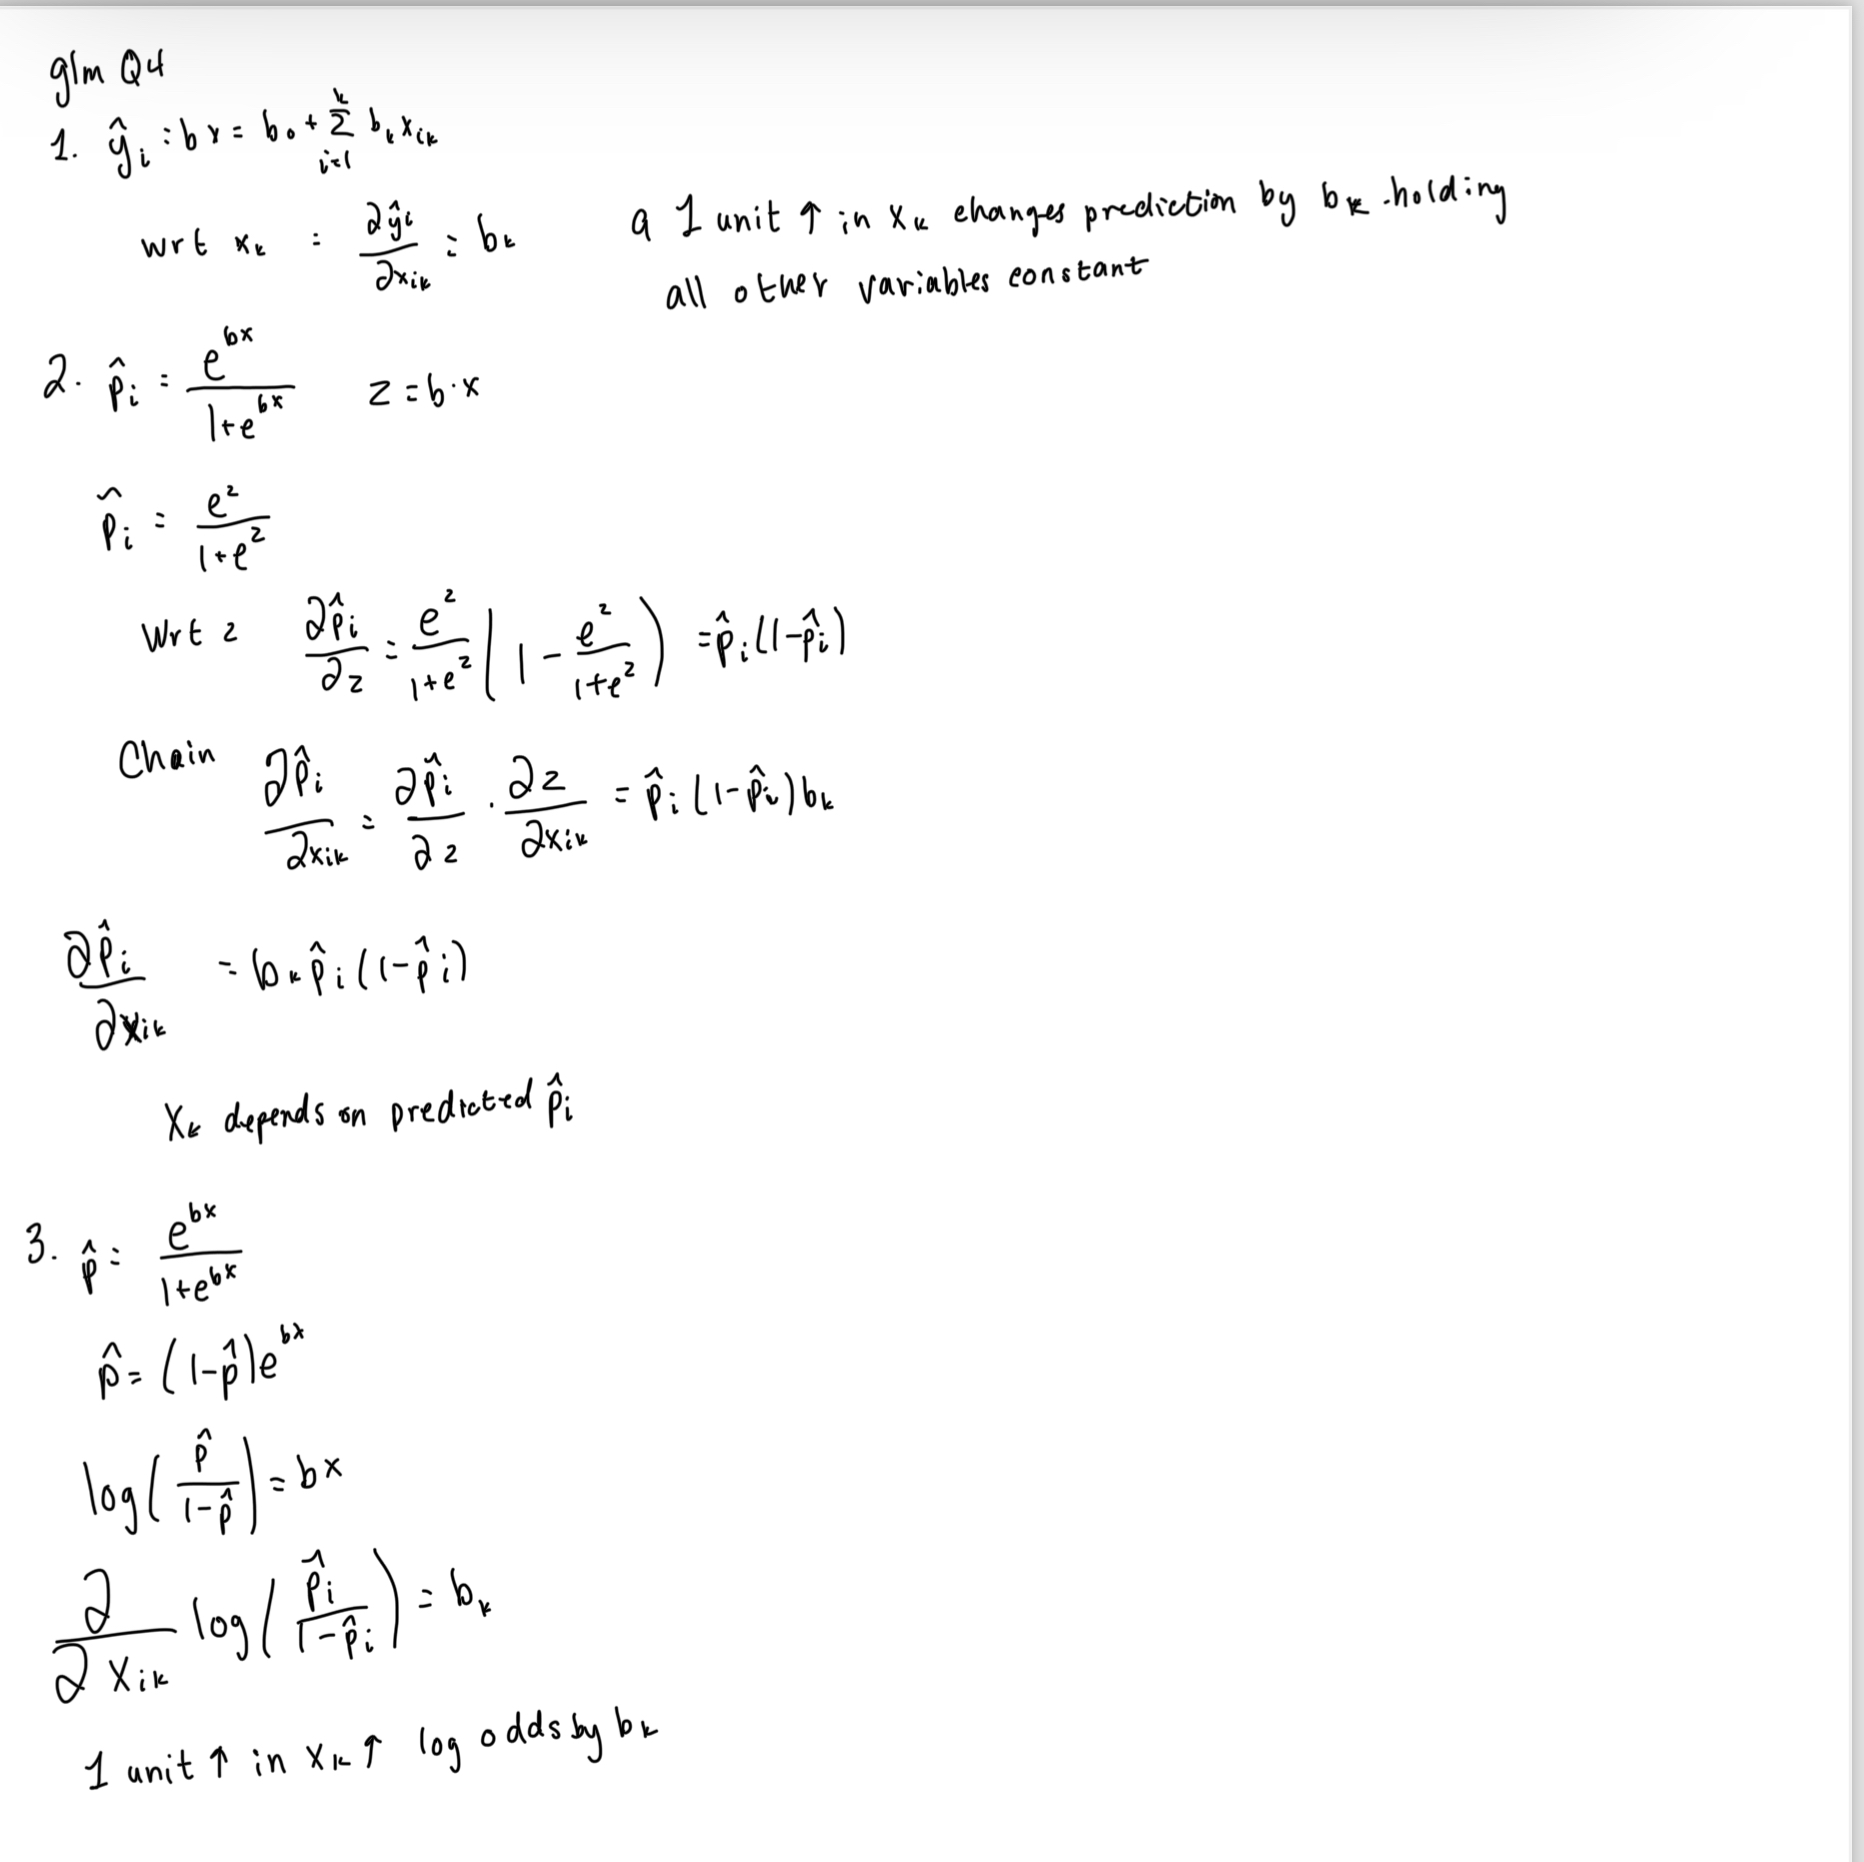